# v6 — content_param_density (subpoblación POST)

**Base:** `features_v3.parquet` (22 features) + 1 candidata en memoria  
**MLflow experiment:** `mlsec-model-a`

## Hipótesis

v5 identificó que el 51% de los FP restantes son POST sin indicadores de payload. El modelo los confunde con ataques por `content_length` y `content_param_count` altos, pero no puede distinguir un POST normal con 5 parámetros de un POST malicioso con 5 parámetros.

**Feature candidata:** `content_param_density` = `content_param_count / content_length.clip(1)` — la densidad de parámetros relativa al tamaño del body. Un POST malicioso podría tener parámetros más densos (payload comprimido) o más esparsos (valores largos inyectados) que un formulario normal.

**Protocolo:** análisis en subpoblación POST → correlación con label → si hay señal, incorporar al dataset en memoria → entrenar 4 modelos → medir impacto vs v5.

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, recall_score, precision_score,
)
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

# PROJECT_ROOT
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "mkdocs.yml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH  = PROJECT_ROOT / "data" / "processed" / "csic2010" / "features_v3.parquet"
MLFLOW_DB  = PROJECT_ROOT / "mlflow.db"
EXPERIMENT = "mlsec-model-a"

mlflow.set_tracking_uri("sqlite:////" + str(MLFLOW_DB).lstrip("/"))
mlflow.set_experiment(EXPERIMENT)

RANDOM_STATE   = 42
MIN_RECALL     = 0.95
MIN_PRECISION  = 0.85
MIN_RECALL_VAL = 0.955  # calibrado en v5

# Resultados v5 — referencia para calcular deltas
V5_RESULTS = {
    "LogisticRegression": {"roc_auc": 0.8086, "recall": 0.9691, "precision": 0.4738, "fp": 4047},
    "RandomForest":       {"roc_auc": 0.9605, "recall": 0.9444, "precision": 0.7991, "fp":  893},
    "XGBoost":            {"roc_auc": 0.9635, "recall": 0.9572, "precision": 0.7726, "fp": 1059},
    "LightGBM":           {"roc_auc": 0.9660, "recall": 0.9556, "precision": 0.7921, "fp":  943},
}

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"MLflow DB    : {MLFLOW_DB} — existe: {MLFLOW_DB.exists()}")
print(f"Data path    : {DATA_PATH} — existe: {DATA_PATH.exists()}")
print(f"MIN_RECALL_VAL: {MIN_RECALL_VAL} (calibrado en v5)")

PROJECT_ROOT : /Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec
MLflow DB    : /Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec/mlflow.db — existe: True
Data path    : /Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec/data/processed/csic2010/features_v3.parquet — existe: True
MIN_RECALL_VAL: 0.955 (calibrado en v5)


## 1. Carga y split

In [2]:
df = pd.read_parquet(DATA_PATH)
print(f"Shape: {df.shape}  |  Features: {len(df.columns)-1}")
print(f"Distribución label: {df['label'].value_counts().to_dict()}")

Shape: (61065, 23)  |  Features: 22
Distribución label: {0: 36000, 1: 25065}


## 2. Análisis subpoblación POST — content_param_density

Protocolo: calcular correlación con label **exclusivamente en los requests POST**, donde `content` tiene significado real. La correlación global diluye la señal porque los GETs tienen content=0 por definición del protocolo.

In [3]:
# Construir content_param_density en memoria
df["content_param_density"] = (
    df["content_param_count"] / df["content_length"].clip(lower=1)
).astype("float32")

# Subpoblación POST
post_df = df[df["method_is_post"] == 1].copy()
get_df  = df[df["method_is_get"]  == 1].copy()

print(f"Total  : {len(df):6d}  | label=1: {df['label'].mean():.1%}")
print(f"POST   : {len(post_df):6d}  | label=1: {post_df['label'].mean():.1%}")
print(f"GET    : {len(get_df):6d}  | label=1: {get_df['label'].mean():.1%}")

corr_global = df["content_param_density"].corr(df["label"])
corr_post   = post_df["content_param_density"].corr(post_df["label"])
corr_get    = get_df["content_param_density"].corr(get_df["label"])

print(f"\nCorrelación content_param_density vs label:")
print(f"  Global : {corr_global:+.3f}")
print(f"  POST   : {corr_post:+.3f}  ← subpoblación relevante")
print(f"  GET    : {corr_get:+.3f}  (GET siempre tiene content=0, señal vacía)")

Total  :  61065  | label=1: 41.0%
POST   :  17580  | label=1: 54.5%
GET    :  43088  | label=1: 35.0%

Correlación content_param_density vs label:
  Global : +0.066
  POST   : -0.216  ← subpoblación relevante
  GET    : +nan  (GET siempre tiene content=0, señal vacía)


In [4]:
# Distribución en POST — normal vs ataque
post_normal = post_df[post_df["label"] == 0]
post_attack = post_df[post_df["label"] == 1]

print("Estadísticas content_param_density — subpoblación POST")
print("="*60)
print(f"{'Estadístico':<15} {'Normal POST':>15} {'Ataque POST':>15}")
print("-"*50)
for stat in ["mean", "median", "std", "max"]:
    fn = getattr(pd.Series, stat)
    v_norm = fn(post_normal["content_param_density"])
    v_att  = fn(post_attack["content_param_density"])
    print(f"{stat:<15} {v_norm:>15.4f} {v_att:>15.4f}")

# Percentiles
print()
print(f"{'Percentil':<15} {'Normal POST':>15} {'Ataque POST':>15}")
print("-"*50)
for p in [25, 50, 75, 90, 95]:
    v_norm = post_normal["content_param_density"].quantile(p/100)
    v_att  = post_attack["content_param_density"].quantile(p/100)
    print(f"P{p:<14} {v_norm:>15.4f} {v_att:>15.4f}")

Estadísticas content_param_density — subpoblación POST
Estadístico         Normal POST     Ataque POST
--------------------------------------------------
mean                     0.0837          0.0604
median                   0.0633          0.0533
std                      0.0647          0.0389
max                      0.2500          0.2500

Percentil           Normal POST     Ataque POST
--------------------------------------------------
P25                      0.0516          0.0413
P50                      0.0633          0.0533
P75                      0.0789          0.0714
P90                      0.2500          0.0820
P95                      0.2500          0.1667


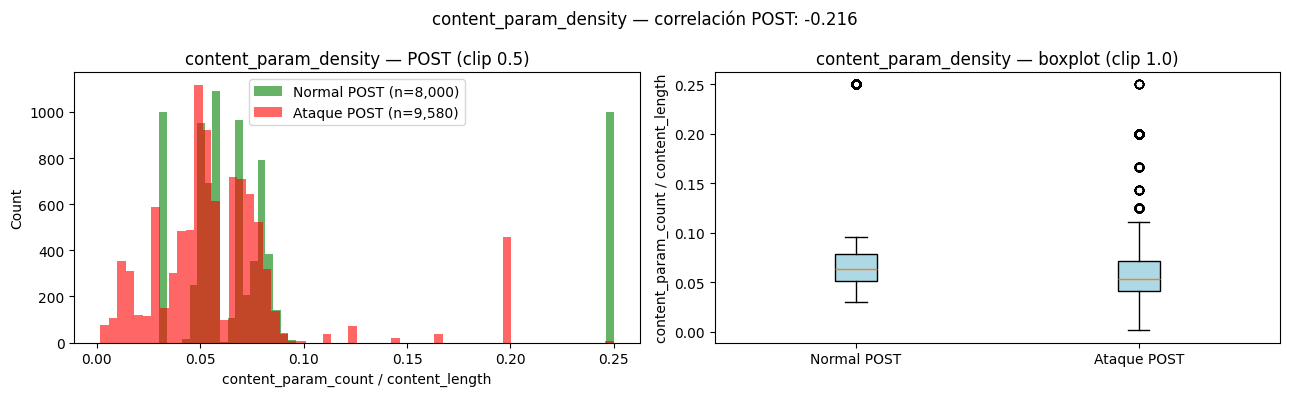

In [5]:
# Visualización — distribución POST normal vs ataque
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma
ax = axes[0]
ax.hist(post_normal["content_param_density"].clip(upper=0.5), bins=60,
        alpha=0.6, color="green", label=f"Normal POST (n={len(post_normal):,})")
ax.hist(post_attack["content_param_density"].clip(upper=0.5), bins=60,
        alpha=0.6, color="red",   label=f"Ataque POST (n={len(post_attack):,})")
ax.set_title("content_param_density — POST (clip 0.5)")
ax.set_xlabel("content_param_count / content_length")
ax.set_ylabel("Count")
ax.legend()

# Boxplot
ax = axes[1]
data_plot = [
    post_normal["content_param_density"].clip(upper=1.0).values,
    post_attack["content_param_density"].clip(upper=1.0).values,
]
ax.boxplot(data_plot, labels=["Normal POST", "Ataque POST"], patch_artist=True,
           boxprops=dict(facecolor="lightblue"))
ax.set_title("content_param_density — boxplot (clip 1.0)")
ax.set_ylabel("content_param_count / content_length")

plt.suptitle(f"content_param_density — correlación POST: {corr_post:+.3f}", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Decisión sobre content_param_density

In [6]:
print("Decisión — content_param_density")
print("="*55)
print(f"  Correlación POST: {corr_post:+.3f}")

SIGNAL_THRESHOLD = 0.05  # umbral mínimo de correlación para considerar señal

if abs(corr_post) >= SIGNAL_THRESHOLD:
    print(f"  → Señal presente (|corr| ≥ {SIGNAL_THRESHOLD}) — incorporar al dataset en memoria")
    HAS_SIGNAL = True
else:
    print(f"  → Señal insuficiente (|corr| < {SIGNAL_THRESHOLD}) — no se agrega")
    print("  → El impacto en métricas dirá la última palabra (el modelo puede ver relaciones no-lineales)")
    HAS_SIGNAL = False

Decisión — content_param_density
  Correlación POST: -0.216
  → Señal presente (|corr| ≥ 0.05) — incorporar al dataset en memoria


## 4. Construir dataset v6 en memoria (23 features)

In [7]:
# content_param_density ya está en df (calculada en la celda de análisis)
feature_cols_v6 = [
    # v1 — method
    "method_is_get", "method_is_post", "method_is_put",
    # v1 — url
    "url_length", "url_param_count", "url_pct_density",
    # v4 — url structure
    "url_path_depth", "url_query_length", "url_has_query",
    # v1 — url indicators
    "url_has_pct27", "url_has_pct3c", "url_has_dashdash", "url_has_script", "url_has_select",
    # v1 — content
    "content_length",
    # v3 — content density + params
    "content_pct_density", "content_param_count",
    # v6 — content param density (nueva)
    "content_param_density",
    # v1 — content indicators
    "content_has_pct27", "content_has_pct3c", "content_has_dashdash", "content_has_script", "content_has_select",
    # label
    "label",
]

df_v6 = df[feature_cols_v6].copy()
print(f"Dataset v6: {df_v6.shape}  |  {len(feature_cols_v6)-1} features + label")
print(f"Nueva feature: content_param_density  (float32)")

# Verificar que no hay NaN
nans = df_v6.isnull().sum().sum()
print(f"NaN en el dataset: {nans}")

Dataset v6: (61065, 24)  |  23 features + label
Nueva feature: content_param_density  (float32)
NaN en el dataset: 0


In [8]:
# Split — misma semilla
X = df_v6.drop(columns=["label"]).values.astype("float32")
y = df_v6["label"].values
feature_names_v6 = df_v6.drop(columns=["label"]).columns.tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)
print(f"Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}")

# Escalado — features continuas, fit solo en train
continuous_features = ["url_length", "url_query_length", "content_length"]
continuous_idx = [feature_names_v6.index(c) for c in continuous_features]

scaler = StandardScaler()
X_train[:, continuous_idx] = scaler.fit_transform(X_train[:, continuous_idx])
X_val[:, continuous_idx]   = scaler.transform(X_val[:, continuous_idx])
X_test[:, continuous_idx]  = scaler.transform(X_test[:, continuous_idx])
print(f"Escaladas: {continuous_features}")

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight: {scale:.3f}")

Train: 42745 | Val: 9160 | Test: 9160
Escaladas: ['url_length', 'url_query_length', 'content_length']
scale_pos_weight: 1.436


## 5. Entrenamiento v6 — 4 modelos

In [9]:
def find_best_threshold(y_true, y_proba, min_recall=MIN_RECALL):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    mask = recalls[:-1] >= min_recall
    if not mask.any():
        best_idx = np.argmax(recalls[:-1])
    else:
        best_idx = np.where(mask, precisions[:-1], 0).argmax()
    return float(thresholds[best_idx])


def evaluate(y_true, y_pred, y_proba, split_name):
    auc = roc_auc_score(y_true, y_proba)
    rc  = recall_score(y_true, y_pred)
    pr  = precision_score(y_true, y_pred)
    cm  = confusion_matrix(y_true, y_pred)
    fp  = cm[0, 1]
    print(f"  {split_name}")
    print(f"    ROC-AUC={auc:.4f}  Recall={rc:.4f} {'✅' if rc>=MIN_RECALL else '❌'}  "
          f"Precision={pr:.4f} {'✅' if pr>=MIN_PRECISION else '❌'}  FP={fp}")
    return {"roc_auc": auc, "recall": rc, "precision": pr, "fp": fp}


def run_model_mlflow(name, model):
    algo_slug = name.lower().replace(" ", "")
    run_name  = f"model-a-{algo_slug}-features-v6"

    with mlflow.start_run(run_name=run_name):
        model.fit(X_train, y_train)

        val_proba  = model.predict_proba(X_val)[:, 1]
        threshold  = find_best_threshold(y_val, val_proba, min_recall=MIN_RECALL_VAL)
        val_pred   = (val_proba >= threshold).astype(int)
        test_proba = model.predict_proba(X_test)[:, 1]
        test_pred  = (test_proba >= threshold).astype(int)

        print(f"\n{'='*55}")
        print(f"{name}  |  threshold={threshold:.4f}")
        val_metrics  = evaluate(y_val,  val_pred,  val_proba,  "Val ")
        test_metrics = evaluate(y_test, test_pred, test_proba, "Test")

        v5 = V5_RESULTS.get(name.replace(" ", ""), {})
        if v5:
            print(f"  Δ vs v5 → ROC-AUC:{test_metrics['roc_auc']-v5['roc_auc']:+.4f}  "
                  f"Recall:{test_metrics['recall']-v5['recall']:+.4f}  "
                  f"Precision:{test_metrics['precision']-v5['precision']:+.4f}  "
                  f"FP:{test_metrics['fp']-v5['fp']:+d}")

        mlflow.log_param("model", name)
        mlflow.log_param("features_version", "v6")
        mlflow.log_param("n_features", X_train.shape[1])
        mlflow.log_param("threshold", round(threshold, 4))
        mlflow.log_param("min_recall_val", MIN_RECALL_VAL)
        mlflow.log_param("new_features", "content_param_density")
        for k, v in test_metrics.items():
            mlflow.log_metric(k, round(v, 4))
        mlflow.log_metric("recall_val",    round(val_metrics["recall"],    4))
        mlflow.log_metric("precision_val", round(val_metrics["precision"], 4))

        run_id = mlflow.active_run().info.run_id[:8]
        print(f"  MLflow: {run_id}  {run_name}")

    return model, threshold, test_metrics, test_pred, test_proba

In [10]:
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
_, _, lr_metrics, _, _ = run_model_mlflow("LogisticRegression", lr)


LogisticRegression  |  threshold=0.1919
  Val 
    ROC-AUC=0.8157  Recall=0.9646 ✅  Precision=0.4717 ❌  FP=4062
  Test
    ROC-AUC=0.8202  Recall=0.9697 ✅  Precision=0.4739 ❌  FP=4047
  Δ vs v5 → ROC-AUC:+0.0116  Recall:+0.0006  Precision:+0.0001  FP:+0
  MLflow: c7c04902  model-a-logisticregression-features-v6


In [11]:
rf = RandomForestClassifier(
    n_estimators=200, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
_, _, rf_metrics, _, _ = run_model_mlflow("RandomForest", rf)


RandomForest  |  threshold=0.1690
  Val 
    ROC-AUC=0.9607  Recall=0.9564 ✅  Precision=0.7649 ❌  FP=1105
  Test
    ROC-AUC=0.9606  Recall=0.9484 ❌  Precision=0.7783 ❌  FP=1016
  Δ vs v5 → ROC-AUC:+0.0001  Recall:+0.0040  Precision:-0.0208  FP:+123
  MLflow: 85c4abd2  model-a-randomforest-features-v6


In [12]:
xgb = XGBClassifier(
    n_estimators=200, scale_pos_weight=scale,
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
_, _, xgb_metrics, _, _ = run_model_mlflow("XGBoost", xgb)


XGBoost  |  threshold=0.1796
  Val 
    ROC-AUC=0.9610  Recall=0.9588 ✅  Precision=0.7578 ❌  FP=1152
  Test
    ROC-AUC=0.9634  Recall=0.9574 ✅  Precision=0.7719 ❌  FP=1064
  Δ vs v5 → ROC-AUC:-0.0001  Recall:+0.0002  Precision:-0.0007  FP:+5
  MLflow: 318286bd  model-a-xgboost-features-v6


In [13]:
lgbm = LGBMClassifier(
    n_estimators=200, scale_pos_weight=scale,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgbm_model, lgbm_threshold, lgbm_metrics, lgbm_pred, lgbm_proba = run_model_mlflow("LightGBM", lgbm)


LightGBM  |  threshold=0.2903
  Val 
    ROC-AUC=0.9646  Recall=0.9556 ✅  Precision=0.7867 ❌  FP=974
  Test
    ROC-AUC=0.9661  Recall=0.9548 ✅  Precision=0.7928 ❌  FP=938
  Δ vs v5 → ROC-AUC:+0.0001  Recall:-0.0008  Precision:+0.0007  FP:-5
  MLflow: 88f4e819  model-a-lightgbm-features-v6


In [14]:
# Tabla resumen — v6 vs v5
results = {
    "LogisticRegression": lr_metrics,
    "RandomForest":       rf_metrics,
    "XGBoost":            xgb_metrics,
    "LightGBM":           lgbm_metrics,
}

print("\nResumen v6 vs v5")
print("="*90)
header = f"{'Modelo':<22} {'ROC-AUC':>8} {'Δv5':>7} {'Recall':>8} {'Δv5':>7} {'Precision':>10} {'Δv5':>7} {'FP':>6} {'Δv5':>7}"
print(header)
print("-"*90)
for name, m in results.items():
    v5 = V5_RESULTS.get(name, {})
    if v5:
        print(f"{name:<22} {m['roc_auc']:>8.4f} {m['roc_auc']-v5['roc_auc']:>+7.4f} "
              f"{m['recall']:>8.4f} {m['recall']-v5['recall']:>+7.4f} "
              f"{m['precision']:>10.4f} {m['precision']-v5['precision']:>+7.4f} "
              f"{m['fp']:>6d} {m['fp']-v5['fp']:>+7d}")
print("="*90)
print(f"Criterios: Recall ≥ {MIN_RECALL}  |  Precision ≥ {MIN_PRECISION}  |  min_recall_val={MIN_RECALL_VAL}")


Resumen v6 vs v5
Modelo                  ROC-AUC     Δv5   Recall     Δv5  Precision     Δv5     FP     Δv5
------------------------------------------------------------------------------------------
LogisticRegression       0.8202 +0.0116   0.9697 +0.0006     0.4739 +0.0001   4047      +0
RandomForest             0.9606 +0.0001   0.9484 +0.0040     0.7783 -0.0208   1016    +123
XGBoost                  0.9634 -0.0001   0.9574 +0.0002     0.7719 -0.0007   1064      +5
LightGBM                 0.9661 +0.0001   0.9548 -0.0008     0.7928 +0.0007    938      -5
Criterios: Recall ≥ 0.95  |  Precision ≥ 0.85  |  min_recall_val=0.955


## 6. Feature importance — LightGBM

In [15]:
importances = lgbm_model.feature_importances_
fi_df = pd.DataFrame({
    "feature":    feature_names_v6,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Feature importance — LightGBM v6")
print(fi_df.to_string(index=False))

# Posición de la nueva feature
rank = fi_df[fi_df["feature"] == "content_param_density"].index[0] + 1 if "content_param_density" in fi_df["feature"].values else None
cpd_imp = fi_df[fi_df["feature"] == "content_param_density"]["importance"].values
print(f"\ncontent_param_density → importance: {cpd_imp}")

Feature importance — LightGBM v6
              feature  importance
           url_length        1575
  content_pct_density         959
       content_length         937
     url_query_length         710
      url_pct_density         691
content_param_density         566
       url_path_depth         236
      url_param_count          71
        method_is_put          52
        url_has_pct27          46
    content_has_pct27          45
       url_has_script          31
       method_is_post          29
        method_is_get          21
       url_has_select          20
 content_has_dashdash           4
    content_has_pct3c           4
  content_param_count           3
   content_has_script           0
     url_has_dashdash           0
        url_has_pct3c           0
        url_has_query           0
   content_has_select           0

content_param_density → importance: [566]


## 7. Conclusiones v6

In [16]:
lgbm_recall    = lgbm_metrics["recall"]
lgbm_precision = lgbm_metrics["precision"]
lgbm_fp        = lgbm_metrics["fp"]
v5_lgbm        = V5_RESULTS["LightGBM"]

print("Correlación content_param_density en POST:")
print(f"  {corr_post:+.3f}")
print()
print("LightGBM v6 vs v5:")
print(f"  Recall    : {lgbm_recall:.4f}  {'✅' if lgbm_recall >= MIN_RECALL else '❌'}  "
      f"(Δ {lgbm_recall-v5_lgbm['recall']:+.4f})")
print(f"  Precision : {lgbm_precision:.4f}  {'✅' if lgbm_precision >= MIN_PRECISION else '❌'}  "
      f"(Δ {lgbm_precision-v5_lgbm['precision']:+.4f})")
print(f"  FP        : {lgbm_fp}  (Δ {lgbm_fp-v5_lgbm['fp']:+d})")
print(f"  Gap Precision restante: {MIN_PRECISION - lgbm_precision:.4f}")
print()

if lgbm_precision > v5_lgbm["precision"] and lgbm_recall >= MIN_RECALL:
    print("→ content_param_density tiene señal: Precision mejoró con Recall mantenido")
    print("→ Decisión: incorporar al preprocessing oficial (preprocess_csic_v4.py)")
elif lgbm_precision < v5_lgbm["precision"]:
    print("→ content_param_density no mejoró Precision — feature descartada")
    print("→ Próximo paso: analizar otras señales en la subpoblación POST")
else:
    print("→ Resultado mixto — evaluar si la mejora es consistente entre modelos")

Correlación content_param_density en POST:
  -0.216

LightGBM v6 vs v5:
  Recall    : 0.9548  ✅  (Δ -0.0008)
  Precision : 0.7928  ❌  (Δ +0.0007)
  FP        : 938  (Δ -5)
  Gap Precision restante: 0.0572

→ content_param_density tiene señal: Precision mejoró con Recall mantenido
→ Decisión: incorporar al preprocessing oficial (preprocess_csic_v4.py)
